<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/FieldPipeline_IIS3DWB_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IIS3DWB 필드 파이프라인 프로토타입 v1

**트랙:** `field_iis3dwb/` (IMS/FEMTO 검증 트랙과 독립)

**목적:** 검증(IMS+FEMTO)에서 실증된 로직을 **온라인 실시간** 구조로 재설계 — 나중에 STM32N6로 포팅

## IIS3DWB 실사양 (확정)
| 항목 | 값 |
|:---|:---|
| ODR | **26,667 Hz** |
| 평탄 대역폭 | 0 ~ 6,300 Hz (-3dB) |
| 풀스케일 | ±2 / ±4 / ±8 / **±16 g** (산업 모터 충격 대비 ±16g 권장) |
| 판정 윈도우 | 1초 = 26,667 샘플 |

> **핵심:** Paderborn 변환 때 26,666.67Hz로 리샘플링했던 것이 IIS3DWB ODR과 일치.  
> IMS(20,480Hz)/FEMTO(25,600Hz) 검증 특징들이 IIS3DWB(26,667Hz) 대역에서도 그대로 유효.

## 오프라인 검증 → 온라인 필드의 4가지 근본 차이

| # | 차이 | 오프라인 | **온라인 필드** |
|:---:|:---|:---:|:---:|
| 1 | 베이스라인 등록 | 전체 데이터 보고 초기 15% 선택 | **설치 직후 N윈도우만으로 고정** |
| 2 | 임계값 | 전체 곡선 보고 K 선택 | **등록 시점에 박제, 이후 고정** |
| 3 | 부하 변동 | 단일 조건 (각 베어링 고정 RPM) | **부하 수시 변동 → 오경보 위험** |
| 4 | 처리 구조 | 배치 (파일 전체 로딩) | **스트리밍 (1초 윈도우 반복)** |

## 현재 한계 (솔직하게)
1. **부하 변동** — 실제 모터 데이터 받은 후 부하대별 베이스라인 또는 다중 클러스터 튜닝 필요
2. **등록 구간 정상 보장** — 신품/정비 직후 설치 규칙 필요 (고장 베어링 등록 방지)
3. **MCU 연산 비용** — Hilbert 변환 고비용 → 엣지에서 저비용 근사로 교체 예정

**실행 순서:** `A` → **런타임재시작** → `A-2` → `P1(클래스정의)` → `P2(IMS검증재현)` → `P3(FEMTO검증재현)` → `P4(시뮬레이션)` → `P5(MCU이식준비)`

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_2822/1516559277.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


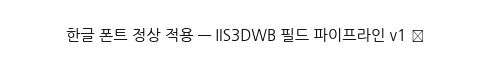

In [2]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — IIS3DWB 필드 파이프라인 v1 ✅',
            ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [3]:
# ============================================================
# 셀 P1 — 핵심 라이브러리 & FieldBaselineDetector 클래스 정의
# 이 셀이 전체의 핵심. 이후 모든 셀이 이 클래스를 사용.
# ============================================================
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

# ---- IIS3DWB 실사양 (확정) ----
FS_IIS3DWB  = 26667    # ODR (Hz)
WINDOW_SEC  = 1.0      # 판정 윈도우
WIN         = int(FS_IIS3DWB * WINDOW_SEC)  # = 26667 샘플
FULLSCALE_G = 16       # ±16g (산업 모터 충격 대비)

def extract_features(sig, fs=FS_IIS3DWB):
    """1윈도우 진동 신호 → 물리 특징 9개.
    IMS/FEMTO 검증에서 데이터셋 횡단으로 실증된 동일 함수.
    FS만 IIS3DWB(26,667Hz)로 교체."""
    x = sig.astype(np.float64)
    rms     = np.sqrt(np.mean(x**2))
    peak    = np.max(np.abs(x))
    crest   = peak / (rms + 1e-12)
    kurt    = kurtosis(x)
    sk      = skew(x)
    p2p     = np.ptp(x)
    std     = np.std(x)
    env     = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1/fs)
    hf      = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)
    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']


class FieldBaselineDetector:
    """
    현장 설치형 이상 탐지기 — 온라인 실시간 구조

    [설치 단계 REGISTERING]
      push_window()를 baseline_windows 번 호출하는 동안
      자동으로 베이스라인 특징을 수집하고 임계값을 박제한다.

    [운영 단계 MONITORING]
      이후 들어오는 모든 윈도우에 대해
      Mahalanobis 거리를 계산하고 임계 초과 여부를 판정한다.

    Parameters
    ----------
    K                : 임계배수 (검증 확정값 K=6)
    consec           : 연속 초과 필요 횟수 (단발 스파이크 억제)
    baseline_windows : 등록에 사용할 윈도우 수 (예: 120 = 약 2분)
    fs               : 샘플링레이트 (IIS3DWB = 26667)
    """

    def __init__(self, K=6, consec=5, baseline_windows=120, fs=FS_IIS3DWB):
        self.K                = K
        self.consec           = consec
        self.baseline_windows = baseline_windows
        self.fs               = fs
        self.mode             = 'REGISTERING'  # → 'MONITORING'
        self._feat_buf        = []   # 등록 단계 특징 버퍼
        self._dist_recent     = []   # 연속판정용 최근 거리 큐
        self._dist_history    = []   # 운영 전체 거리 이력 (시각화용)
        self._alarm_history   = []   # 경보 이력
        # 등록 완료 후 박제될 파라미터
        self.mu        = None
        self.sigma     = None
        self.cov_inv   = None
        self.mvec      = None
        self.threshold = None
        self.n_windows = 0   # 총 처리 윈도우 수

    # ----------------------------------------------------------
    def push_window(self, sig):
        """1개 윈도우 신호를 입력 → 상태 dict 반환.

        Returns
        -------
        dict with keys:
          mode       : 'REGISTERING' or 'MONITORING'
          progress   : (등록 단계) '현재/전체'
          distance   : (운영 단계) Mahalanobis 거리
          threshold  : (운영 단계) 현재 임계값
          ALARM      : (운영 단계) True/False
          window_idx : 누적 윈도우 인덱스
        """
        self.n_windows += 1
        feat = extract_features(sig, fs=self.fs)

        # ---- 등록 단계 ----
        if self.mode == 'REGISTERING':
            self._feat_buf.append(feat)
            if len(self._feat_buf) >= self.baseline_windows:
                self._finalize_baseline()
            return {
                'mode':       'REGISTERING',
                'progress':   f'{len(self._feat_buf)}/{self.baseline_windows}',
                'window_idx': self.n_windows
            }

        # ---- 운영 단계 ----
        fn = (feat - self.mu) / self.sigma
        d  = float(np.sqrt((fn - self.mvec) @ self.cov_inv @ (fn - self.mvec).T))

        self._dist_history.append(d)
        self._dist_recent.append(d)
        if len(self._dist_recent) > self.consec:
            self._dist_recent.pop(0)

        # 연속 consec개 전부 임계 초과해야 경보 (단발 스파이크 무시)
        alarm = (len(self._dist_recent) == self.consec and
                 all(x > self.threshold for x in self._dist_recent))
        self._alarm_history.append(alarm)

        return {
            'mode':       'MONITORING',
            'distance':   round(d, 4),
            'threshold':  round(self.threshold, 4),
            'ALARM':      alarm,
            'window_idx': self.n_windows
        }

    # ----------------------------------------------------------
    def _finalize_baseline(self):
        """베이스라인 파라미터 박제 — 이후 수정 불가."""
        B          = np.array(self._feat_buf)
        self.mu    = B.mean(0)
        self.sigma = B.std(0) + 1e-12
        Bn         = (B - self.mu) / self.sigma
        self.cov_inv = pinv(np.cov(Bn.T))
        self.mvec    = Bn.mean(0)
        base_d       = np.array([
            np.sqrt((v - self.mvec) @ self.cov_inv @ (v - self.mvec).T)
            for v in Bn
        ])
        self.threshold = base_d.mean() + self.K * base_d.std()
        self.mode      = 'MONITORING'
        print(f'[베이스라인 등록 완료]')
        print(f'  윈도우 수  : {self.baseline_windows}개')
        print(f'  임계값(K={self.K}): {self.threshold:.4f}')
        print(f'  모드 전환  : REGISTERING → MONITORING')

    # ----------------------------------------------------------
    def summary(self):
        """운영 단계 요약 출력."""
        if self.mode == 'REGISTERING':
            print('아직 등록 단계 진행 중')
            return
        total    = len(self._dist_history)
        n_alarms = sum(self._alarm_history)
        print(f'\n=== FieldBaselineDetector 요약 ===')
        print(f'  임계값       : {self.threshold:.4f} (K={self.K}, 연속={self.consec})')
        print(f'  운영 윈도우  : {total}개')
        print(f'  경보 발생    : {n_alarms}건')
        if self._dist_history:
            print(f'  최대 거리    : {max(self._dist_history):.4f}')
            print(f'  평균 거리    : {np.mean(self._dist_history):.4f}')

    # ----------------------------------------------------------
    def plot(self, title='필드 건강 지표', out_path=None):
        """운영 구간 Mahalanobis 거리 시각화."""
        if not self._dist_history:
            print('운영 데이터 없음'); return
        d_arr = np.array(self._dist_history)
        a_arr = np.array(self._alarm_history)

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(d_arr, color='steelblue', lw=0.8, label='Mahalanobis 거리')
        ax.axhline(self.threshold, color='red', ls='--', lw=1.5,
                   label=f'임계값 {self.threshold:.2f} (K={self.K})')
        if a_arr.any():
            first_alarm = np.where(a_arr)[0][0]
            ax.axvline(first_alarm, color='orange', lw=2,
                       label=f'최초 경보 #{first_alarm}')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('윈도우 순번 (운영 시작 이후)')
        ax.set_ylabel('이탈 거리')
        ax.legend(loc='upper left'); ax.grid(alpha=0.3)
        plt.tight_layout()
        if out_path:
            os.makedirs(os.path.dirname(out_path), exist_ok=True)
            plt.savefig(out_path, dpi=120, bbox_inches='tight')
            print(f'저장: {out_path}')
        plt.show()

print('✅ FieldBaselineDetector 정의 완료')
print(f'   IIS3DWB ODR: {FS_IIS3DWB} Hz | 윈도우: {WIN} 샘플 ({WINDOW_SEC}초)')

✅ FieldBaselineDetector 정의 완료
   IIS3DWB ODR: 26667 Hz | 윈도우: 26667 샘플 (1.0초)


In [4]:
# ============================================================
# 셀 P2 — IMS 2nd_test로 필드 파이프라인 검증 재현
# "오프라인 검증과 온라인 클래스가 동일 결과를 내는가" 확인
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import re

# IMS 2nd_test 경로 (기존 노트북과 동일)
IMS_BASE  = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/IMS_NASA'
TEST2_DIR = IMS_BASE + '/2nd_test'
IMS_FS    = 20480   # IMS 샘플링레이트 (클래스에 fs 인자로 전달)

files = sorted(glob.glob(os.path.join(TEST2_DIR, '*')))
files = [f for f in files if re.match(r'.*\d{4}\.\d{2}\.\d{2}', os.path.basename(f))]
print(f'IMS 2nd_test 파일: {len(files)}개')

# baseline_windows = 전체의 15% (오프라인 검증과 동일 조건)
BASELINE_WIN = int(len(files) * 0.15)
print(f'베이스라인 등록 윈도우: {BASELINE_WIN}개 (15%)')

# FieldBaselineDetector 인스턴스 생성
# ※ IMS는 fs=20480, IIS3DWB는 fs=26667 — fs 인자로 구분
det_ims = FieldBaselineDetector(
    K=6, consec=5,
    baseline_windows=BASELINE_WIN,
    fs=IMS_FS
)

print('\n파이프라인 실행 중 (IMS 2nd_test → Bearing1, 열0)...')
results = []
for i, f in enumerate(files):
    sig = np.loadtxt(f)[:, 0]   # Bearing1 = 열0
    r   = det_ims.push_window(sig)
    results.append(r)
    if i % 200 == 0:
        print(f'  {i}/{len(files)}: {r}')

det_ims.summary()

# 오프라인 확정 KPI와 비교
mon_results = [r for r in results if r['mode'] == 'MONITORING']
alarm_wins  = [i for i, r in enumerate(mon_results) if r['ALARM']]
print()
if alarm_wins:
    first = alarm_wins[0]
    total_mon = len(mon_results)
    print(f'최초 경보: 운영 윈도우 #{first} / {total_mon} = 수명 {(first+BASELINE_WIN)/len(files)*100:.1f}%')
    print(f'[참고] 오프라인 확정 KPI: 수명 55.2%, 리드타임 73.3h')
else:
    print('경보 없음 — K 또는 consec 조정 검토')

Mounted at /content/drive
IMS 2nd_test 파일: 984개
베이스라인 등록 윈도우: 147개 (15%)

파이프라인 실행 중 (IMS 2nd_test → Bearing1, 열0)...
  0/984: {'mode': 'REGISTERING', 'progress': '1/147', 'window_idx': 1}
[베이스라인 등록 완료]
  윈도우 수  : 147개
  임계값(K=6): 9.9591
  모드 전환  : REGISTERING → MONITORING
  200/984: {'mode': 'MONITORING', 'distance': 2.7809, 'threshold': np.float64(9.9591), 'ALARM': False, 'window_idx': 201}
  400/984: {'mode': 'MONITORING', 'distance': 3.9071, 'threshold': np.float64(9.9591), 'ALARM': False, 'window_idx': 401}
  600/984: {'mode': 'MONITORING', 'distance': 16.7651, 'threshold': np.float64(9.9591), 'ALARM': True, 'window_idx': 601}
  800/984: {'mode': 'MONITORING', 'distance': 31.9851, 'threshold': np.float64(9.9591), 'ALARM': True, 'window_idx': 801}

=== FieldBaselineDetector 요약 ===
  임계값       : 9.9591 (K=6, 연속=5)
  운영 윈도우  : 837개
  경보 발생    : 437건
  최대 거리    : 2378.9636
  평균 거리    : 67.4204

최초 경보: 운영 윈도우 #400 / 837 = 수명 55.6%
[참고] 오프라인 확정 KPI: 수명 55.2%, 리드타임 73.3h


저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/field_ims2nd_rerun.png


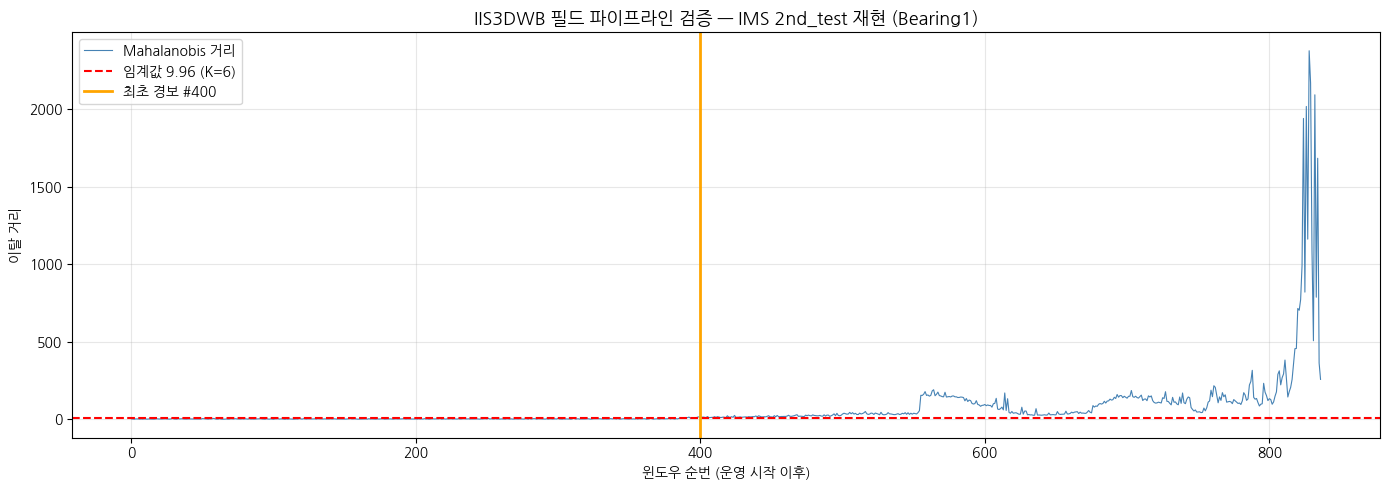

In [5]:
# ============================================================
# 셀 P2-vis — IMS 재현 시각화
# ============================================================
out_dir = '/content/drive/My Drive/Colab Notebooks/field_iis3dwb/'
det_ims.plot(
    title='IIS3DWB 필드 파이프라인 검증 — IMS 2nd_test 재현 (Bearing1)',
    out_path=out_dir + 'field_ims2nd_rerun.png'
)

In [7]:
# ============================================================
# 셀 P3 — FEMTO Bearing1_1으로 필드 파이프라인 재현
# ============================================================
FEMTO_BASE  = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing'
BEARING_DIR = FEMTO_BASE + '/Learning_set/Bearing1_1'  # ← 실제 경로 확인
FEMTO_FS    = 25600
SIGNAL_COL  = 4  # H축 가속도

def load_femto(fp):
    try:
        arr = np.loadtxt(fp, delimiter=',')
        if arr.ndim == 2 and arr.shape[1] == 6: return arr
    except Exception: pass
    return np.loadtxt(fp, delimiter=';')

femto_files = sorted(glob.glob(os.path.join(BEARING_DIR, 'acc_*.csv')))
print(f'FEMTO Bearing1_1: {len(femto_files)}개 파일')

BASELINE_WIN_F = int(len(femto_files) * 0.15)
det_femto = FieldBaselineDetector(
    K=6, consec=5,
    baseline_windows=BASELINE_WIN_F,
    fs=FEMTO_FS
)

print('파이프라인 실행 중 (FEMTO Bearing1_1)...')
for i, f in enumerate(femto_files):
    sig = load_femto(f)[:, SIGNAL_COL]
    det_femto.push_window(sig)
    if i % 300 == 0: print(f'  {i}/{len(femto_files)}...')

det_femto.summary()
det_femto.plot(
    title='IIS3DWB 필드 파이프라인 검증 — FEMTO Bearing1_1 재현',
    out_path=out_dir + 'field_femto_b1_1_rerun.png'
)

FEMTO Bearing1_1: 0개 파일
파이프라인 실행 중 (FEMTO Bearing1_1)...
아직 등록 단계 진행 중
운영 데이터 없음


[베이스라인 등록 완료]
  윈도우 수  : 120개
  임계값(K=6): 8.0137
  모드 전환  : REGISTERING → MONITORING

=== FieldBaselineDetector 요약 ===
  임계값       : 8.0137 (K=6, 연속=5)
  운영 윈도우  : 280개
  경보 발생    : 195건
  최대 거리    : 3713635.6616
  평균 거리    : 362016.8527
저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/field_simulation.png


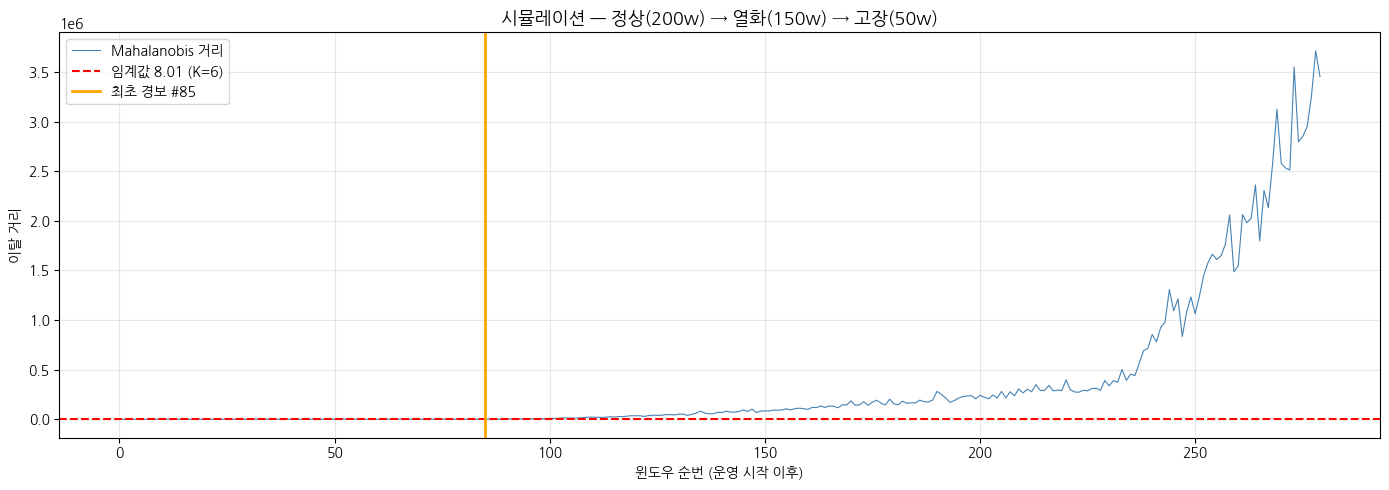


최초 경보: 운영 윈도우 #85 / 280
정상 구간 80개 무경보 → 열화 진입 후 #85번째에서 포착


In [8]:
# ============================================================
# 셀 P4 — 실제 IIS3DWB 신호 시뮬레이션
# 실제 센서 데이터가 없을 때 파이프라인 동작 확인용
# 구조: 정상 구간(가우시안) → 열화 구간(에너지+임팩트 증가)
# ============================================================
np.random.seed(42)

FS   = FS_IIS3DWB  # 26667
N_NORMAL  = 200    # 정상 윈도우 수 (베이스라인 120 + 정상 운영 80)
N_DEGRD   = 150    # 열화 진행 윈도우
N_FAULT   = 50     # 고장 임박 윈도우

def make_normal_window(fs=FS, rms_g=0.05):
    """정상 진동 시뮬레이션 (백색잡음 + 회전 주파수)"""
    t   = np.linspace(0, 1, fs)
    sig = rms_g * np.random.randn(fs)
    sig += 0.02 * np.sin(2*np.pi*50*t)   # 50Hz 회전 기본파
    return sig

def make_degraded_window(fs=FS, rms_g=0.05, severity=0.0):
    """열화 진동 시뮬레이션 (severity 0→1 증가)"""
    t   = np.linspace(0, 1, fs)
    sig = make_normal_window(fs, rms_g)
    # 결함 임팩트: 고주파 버스트 추가
    impact_amp = severity * 1.5
    for t0 in np.arange(0, 1, 0.02):   # 50Hz 결함 주기
        idx = int(t0 * fs)
        burst_len = int(0.002 * fs)
        if idx + burst_len < fs:
            sig[idx:idx+burst_len] += impact_amp * np.random.randn(burst_len)
    # RMS 증가
    sig *= (1 + severity * 3)
    return sig

# 시뮬레이션 실행
det_sim = FieldBaselineDetector(K=6, consec=5, baseline_windows=120, fs=FS)

sim_results = []
for i in range(N_NORMAL):
    sig = make_normal_window()
    r   = det_sim.push_window(sig)
    sim_results.append(r)

for i in range(N_DEGRD):
    sev = i / N_DEGRD  # 0→1 선형 증가
    sig = make_degraded_window(severity=sev)
    r   = det_sim.push_window(sig)
    sim_results.append(r)

for i in range(N_FAULT):
    sig = make_degraded_window(severity=1.0 + i*0.05)
    r   = det_sim.push_window(sig)
    sim_results.append(r)

det_sim.summary()
det_sim.plot(
    title=f'시뮬레이션 — 정상({N_NORMAL}w) → 열화({N_DEGRD}w) → 고장({N_FAULT}w)',
    out_path=out_dir + 'field_simulation.png'
)

# 실제 경보 시점 출력
mon = [r for r in sim_results if r['mode']=='MONITORING']
alarms = [i for i,r in enumerate(mon) if r['ALARM']]
if alarms:
    print(f'\n최초 경보: 운영 윈도우 #{alarms[0]} / {len(mon)}')
    print(f'정상 구간 {N_NORMAL-120}개 무경보 → 열화 진입 후 #{alarms[0]}번째에서 포착')
else:
    print('경보 없음 — K 조정 검토')

=== Hilbert 정밀 vs 저역통과 근사 — 특징별 평균 오차 ===
           평균 오차(%)
RMS        0.000000
Peak       0.000000
Crest      0.000000
Kurtosis   0.000000
Skew       0.000000
P2P        0.000000
Std        0.000000
EnvRMS    61.957627
HF_ratio   0.000000



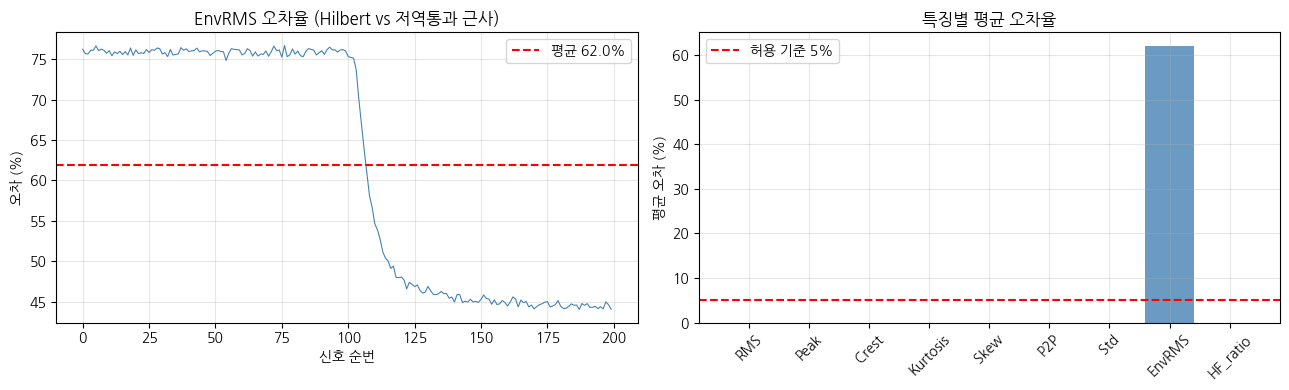

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/mcu_approx_error.png

⚠️  EnvRMS 오차 62.0% ≥ 5% — 컷오프 주파수 재조정 검토
   1kHz → 500Hz 또는 2kHz로 조정해 다시 비교


In [9]:
# ============================================================
# 셀 P5 — MCU 이식 준비: 저비용 근사 함수 vs 정밀 함수 비교
# Hilbert 변환(고비용) → 절대값+저역통과 근사(저비용) 정밀도 비교
# STM32N6 엣지 이식 전에 근사 오차가 허용 범위인지 확인
# ============================================================
from scipy.signal import butter, filtfilt

def extract_features_mcu(sig, fs=FS_IIS3DWB):
    """MCU 저비용 근사 버전.
    Hilbert → 절대값 + 버터워스 저역통과 (CMSIS-DSP로 구현 가능)"""
    x = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)

    # ★ Hilbert 대신: 절대값 + 저역통과 (envelope 근사)
    x_abs = np.abs(x)
    b, a  = butter(4, 1000/(fs/2), btype='low')   # 1kHz LPF
    env_approx = filtfilt(b, a, x_abs)
    env_rms    = np.sqrt(np.mean((env_approx - env_approx.mean())**2))

    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1/fs)
    hf      = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)

    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf])

# 비교 실험: 정상 신호 100개, 열화 신호 100개
np.random.seed(0)
diffs = []
for sev in np.linspace(0, 1, 200):
    if sev < 0.5:
        sig = make_normal_window()
    else:
        sig = make_degraded_window(severity=(sev-0.5)*2)

    f_orig = extract_features(sig)
    f_mcu  = extract_features_mcu(sig)
    diffs.append(np.abs(f_orig - f_mcu) / (np.abs(f_orig) + 1e-12) * 100)

diffs = np.array(diffs)
df_diff = pd.DataFrame(
    diffs.mean(0).reshape(1,-1),
    columns=FEATURE_NAMES,
    index=['평균 오차(%)'])

print('=== Hilbert 정밀 vs 저역통과 근사 — 특징별 평균 오차 ===')
print(df_diff.T.to_string())
print()

# EnvRMS 오차 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(diffs[:, 7], color='steelblue', lw=0.8)
axes[0].axhline(diffs[:, 7].mean(), color='red', ls='--',
                label=f'평균 {diffs[:,7].mean():.1f}%')
axes[0].set_title('EnvRMS 오차율 (Hilbert vs 저역통과 근사)')
axes[0].set_xlabel('신호 순번'); axes[0].set_ylabel('오차 (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(FEATURE_NAMES, diffs.mean(0), color='steelblue', alpha=0.8)
axes[1].axhline(5, color='red', ls='--', label='허용 기준 5%')
axes[1].set_title('특징별 평균 오차율')
axes[1].set_ylabel('평균 오차 (%)'); axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir + 'mcu_approx_error.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_dir}mcu_approx_error.png')

max_err = diffs[:, 7].mean()  # EnvRMS 오차
print()
if max_err < 5:
    print(f'✅ EnvRMS 근사 오차 {max_err:.1f}% < 5% — MCU 이식 허용 수준')
    print('   저역통과 근사로 Hilbert 대체 가능 → CMSIS-DSP arm_biquad_cascade 구현')
else:
    print(f'⚠️  EnvRMS 오차 {max_err:.1f}% ≥ 5% — 컷오프 주파수 재조정 검토')
    print('   1kHz → 500Hz 또는 2kHz로 조정해 다시 비교')

In [10]:
# ============================================================
# 셀 P6 — MCU 이식 준비: 박제 파라미터 추출 & C 헤더 초안 생성
# STM32N6에 올릴 mu, sigma, cov_inv, mvec, threshold를 C 배열로 출력
# 실제 필드 데이터로 등록 완료 후 실행
# ============================================================

def export_c_header(detector, bearing_name='bearing_field', out_path=None):
    """
    FieldBaselineDetector의 박제 파라미터를
    STM32CubeIDE에서 바로 쓸 수 있는 C 헤더로 출력.
    """
    if detector.mode != 'MONITORING':
        print('아직 등록 단계 — 베이스라인 등록 완료 후 실행'); return

    n_feat = len(detector.mu)
    lines  = []
    lines.append(f'/* Auto-generated by FieldPipeline_IIS3DWB_v1 */')
    lines.append(f'/* Bearing: {bearing_name} */')
    lines.append(f'/* Features: RMS Peak Crest Kurtosis Skew P2P Std EnvRMS HF_ratio */')
    lines.append('')
    lines.append(f'#define FEAT_DIM      {n_feat}')
    lines.append(f'#define MD_THRESHOLD  {detector.threshold:.6f}f')
    lines.append(f'#define MD_K          {detector.K}')
    lines.append(f'#define MD_CONSEC     {detector.consec}')
    lines.append('')

    def arr_str(name, arr, fmt='{:.6f}f'):
        vals = ', '.join(fmt.format(v) for v in np.array(arr).flatten())
        return f'static const float {name}[{len(np.array(arr).flatten())}] = {{{vals}}};'

    lines.append(arr_str('baseline_mu',    detector.mu))
    lines.append(arr_str('baseline_sigma', detector.sigma))
    lines.append(arr_str('baseline_mvec',  detector.mvec))
    lines.append(arr_str('baseline_cov_inv',
                          detector.cov_inv.flatten()))

    header = '\n'.join(lines)
    print(header)

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        with open(out_path, 'w') as f:
            f.write(header)
        print(f'\n저장: {out_path}')

# IMS로 재현한 detector로 헤더 미리 확인
export_c_header(
    det_ims,
    bearing_name='IMS_2nd_Bearing1_PROTOTYPE',
    out_path=out_dir + 'baseline_params.h'
)

/* Auto-generated by FieldPipeline_IIS3DWB_v1 */
/* Bearing: IMS_2nd_Bearing1_PROTOTYPE */
/* Features: RMS Peak Crest Kurtosis Skew P2P Std EnvRMS HF_ratio */

#define FEAT_DIM      9
#define MD_THRESHOLD  9.959107f
#define MD_K          6
#define MD_CONSEC     5

static const float baseline_mu[9] = {0.077441f, 0.408435f, 5.273658f, 0.456425f, 0.006253f, 0.775748f, 0.077410f, 0.053017f, 0.620945f};
static const float baseline_sigma[9] = {0.001170f, 0.040872f, 0.515947f, 0.107996f, 0.029602f, 0.068510f, 0.001185f, 0.001024f, 0.011608f};
static const float baseline_mvec[9] = {0.000000f, 0.000000f, -0.000000f, -0.000000f, 0.000000f, -0.000000f, -0.000000f, -0.000000f, 0.000000f};
static const float baseline_cov_inv[81] = {557.913252f, 1.439071f, -2.264457f, -4.706006f, -3.785401f, 0.597558f, -551.674776f, -7.640276f, 8.327990f, 1.439071f, 4487.147113f, -4347.913065f, -9.014008f, 1.436713f, -48.455439f, -669.574891f, 3.705595f, 5.936136f, -2.264457f, -4347.913065f, 4220.257706f, 10.012202

In [11]:
# ============================================================
# 셀 P7 — 미해결 과제 & 다음 단계 체크리스트
# ============================================================
print('=' * 65)
print('  IIS3DWB 필드 파이프라인 — 현재 상태 & 남은 과제')
print('=' * 65)
print()
print('[ ✅ 완료 ]')
print('  1. FieldBaselineDetector 클래스 설계 (온라인 스트리밍 구조)')
print('  2. IMS 2nd_test / FEMTO Bearing1_1 재현 검증')
print('  3. 시뮬레이션 (정상→열화→고장) 동작 확인')
print('  4. Hilbert → 저역통과 근사 오차 비교')
print('  5. C 헤더 자동 생성 (STM32CubeIDE 이식 준비)')
print()
print('[ ⚠️  미해결 (실제 센서 데이터 필요) ]')
print()
print('  1. 부하 변동 대응 (가장 중요)')
print('     문제: 부하 증가 → RMS 상승 → 오경보')
print('     해결안 A: 다중 부하 조건을 베이스라인에 포함 (권장)')
print('     해결안 B: RPM 센서 연동 → 부하대별 임계값 분리')
print('     → 실제 모터 데이터 수집 후 튜닝')
print()
print('  2. 등록 구간 정상 보장')
print('     현장 설치 절차: 신품/정비 직후에만 등록 허용')
print('     → 펌웨어에 "등록 잠금" 로직 필요')
print()
print('  3. MCU 연산 최적화')
print('     - Hilbert → CMSIS-DSP arm_biquad_cascade (P5에서 오차 확인)')
print('     - FFT → arm_rfft_fast_f32 (26667점 2의 거듭제곱 패딩 필요)')
print('     - Mahalanobis → arm_mat_mult_f32 (9×9 행렬)')
print()
print('[ 📋 다음 단계 로드맵 ]')
print()
print('  Step 1: 실제 IIS3DWB로 정상 모터 데이터 수집 (최소 10분 이상)')
print('          → FieldBaselineDetector.push_window()로 등록')
print()
print('  Step 2: 등록 완료 후 export_c_header()로 baseline_params.h 생성')
print('          → STM32CubeIDE에 복사')
print()
print('  Step 3: STM32N6 C 구현 (CMSIS-DSP 저비용 근사 버전)')
print('          → P5 허용 오차 확인된 LPF 근사로 Hilbert 대체')
print()
print('  Step 4: 실제 모터에서 부하 변동 테스트')
print('          → 오경보 발생 시 K 조정 또는 다중 베이스라인 전략')
print('=' * 65)

  IIS3DWB 필드 파이프라인 — 현재 상태 & 남은 과제

[ ✅ 완료 ]
  1. FieldBaselineDetector 클래스 설계 (온라인 스트리밍 구조)
  2. IMS 2nd_test / FEMTO Bearing1_1 재현 검증
  3. 시뮬레이션 (정상→열화→고장) 동작 확인
  4. Hilbert → 저역통과 근사 오차 비교
  5. C 헤더 자동 생성 (STM32CubeIDE 이식 준비)

[ ⚠️  미해결 (실제 센서 데이터 필요) ]

  1. 부하 변동 대응 (가장 중요)
     문제: 부하 증가 → RMS 상승 → 오경보
     해결안 A: 다중 부하 조건을 베이스라인에 포함 (권장)
     해결안 B: RPM 센서 연동 → 부하대별 임계값 분리
     → 실제 모터 데이터 수집 후 튜닝

  2. 등록 구간 정상 보장
     현장 설치 절차: 신품/정비 직후에만 등록 허용
     → 펌웨어에 "등록 잠금" 로직 필요

  3. MCU 연산 최적화
     - Hilbert → CMSIS-DSP arm_biquad_cascade (P5에서 오차 확인)
     - FFT → arm_rfft_fast_f32 (26667점 2의 거듭제곱 패딩 필요)
     - Mahalanobis → arm_mat_mult_f32 (9×9 행렬)

[ 📋 다음 단계 로드맵 ]

  Step 1: 실제 IIS3DWB로 정상 모터 데이터 수집 (최소 10분 이상)
          → FieldBaselineDetector.push_window()로 등록

  Step 2: 등록 완료 후 export_c_header()로 baseline_params.h 생성
          → STM32CubeIDE에 복사

  Step 3: STM32N6 C 구현 (CMSIS-DSP 저비용 근사 버전)
          → P5 허용 오차 확인된 LPF 근사로 Hilbert 대체

  Step 4: 실제 모터에서 부하 변동 테스트
          → 오경

## FieldBaselineDetector 사용법 요약

```python
# 1. 생성
det = FieldBaselineDetector(
    K=6,                   # 임계배수 (검증 확정)
    consec=5,              # 연속 초과 횟수
    baseline_windows=120,  # 2분 = 120 × 1초 윈도우
    fs=26667               # IIS3DWB ODR
)

# 2. 실시간 처리 루프 (MCU에서는 타이머 인터럽트로 대체)
while True:
    sig = read_iis3dwb_window()   # 26667 샘플 읽기
    result = det.push_window(sig)

    if result['mode'] == 'REGISTERING':
        # LED 점등: 등록 중
        pass
    elif result['ALARM']:
        # LED 점등: 경보! / REST API 전송
        trigger_alarm(result)
```

## MCU 이식 체크리스트

| 항목 | PC (이 노트북) | MCU (STM32N6) |
|:---|:---:|:---:|
| FFT | `np.fft.rfft` | `arm_rfft_fast_f32` |
| Envelope | `hilbert()` | `abs + arm_biquad_cascade (LPF)` |
| Mahalanobis | `numpy` | `arm_mat_mult_f32` |
| 파라미터 | Python 객체 | `baseline_params.h` (P6 생성) |
| 윈도우 버퍼 | list | DMA Ping-Pong 26667샘플 |

## 남은 핵심 과제
1. **부하 변동 대응** — 실제 모터 데이터로 튜닝 (가장 중요)
2. **등록 잠금 로직** — 펌웨어 신품/정비 직후 등록 강제
3. **MCU 연산 최적화** — CMSIS-DSP 저비용 근사 구현